# Lab 2: Fuzzy Q-Learning for CartPole-v1 — Fuzzy State Representation &#215; Q-Learning

> **Aim:** Design and implement a Fuzzy Q-Learning (FQL) agent that learns to balance a pole in the Gymnasium `CartPole-v1` environment by converting the continuous state space into **linguistic (fuzzy) variables**, constructing a **fuzzy rule base**, and applying **Q-learning** over the fuzzy states with an **$\epsilon$-greedy** action policy.

> **Environment:** `CartPole-v1` has a 4-dimensional **continuous** observation space:
> | obs | variable | range |
> |---|---:|---:|
> | $x$ | Cart position | $[-4.8,\ 4.8]$ |
> | $\dot{x}$ | Cart velocity | $(-\infty,\ \infty)$ |
> | $\theta$ | Pole angle (rad) | $[-0.418,\ 0.418]$ |
> | $\dot{\theta}$ | Pole angular velocity | $(-\infty,\ \infty)$ |
>
> and a **discrete** 2-action space (push cart left/right). Because the state space is continuous and infinite, a classic tabular Q-table over grid states is impractical — fuzzy sets let us *quantize gracefully* (overlapping, interpolating bins) and learn one Q-value per fuzzy rule.
> 

### Key Enhancements / Additions Carried Over From Lab 1 & New Workings
- **Clean PRNG seeding** — one local NumPy generator owns Q initialization and action sampling; Gymnasium's stream is seeded once.
- **Deterministic greedy value** — value targets and extracted policies do not consume exploration randomness.
- **Validation-based Early Stopping** — checks every fixed interval plus the final budget episode, then requires two consecutive averages of at least 470.
- **Decoupled exponential $\epsilon$-decay** — exploration horizon is pegged to a fixed episode window, independent of budget.
- **Bounded Robbins-Monro $\alpha$-decay** — learning rate follows Lab 1's schedule with an explicit floor and is tracked per episode.
- **Terminal-aware rewards** — terminal transitions retain the environment reward; shaping applies only to non-terminal transitions.
- **NEW: Proportional (activation-weighted) rule update** vs. classical **winner-rule-only** update — compared directly.
- **NEW: Mixed-resolution fuzzy partitions** — the *curse of dimensionality* is demonstrated: $5^3=125$ uniform rules learn slowly, $2^3=8$ are too coarse; the tuned $2\times4\times4=32$ rule base solves the task.
- **NEW: Membership-function analysis** — triangular vs trapezoidal partitions visualised and compared.

### 1. Environment Setup & Dependencies
- **What was done:** Imported Gymnasium, NumPy, Matplotlib, Seaborn, and Pandas using the virtual environment used in Lab 1.
- **Why it was done:** To instantiate the environment, run fast vectorised matrix/array operations for the fuzzy memberships, and render clean publication-style plots.

In [1]:
%matplotlib inline
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(f"Gymnasium version: {gym.__version__}")
print(f"NumPy version:     {np.__version__}")

Gymnasium version: 1.3.0
NumPy version:     2.5.1


### 2. Converting Continuous States into Fuzzy Linguistic Variables (Task 1)
We define **linguistic labels** over each continuous state variable as interval `[lo, hi]`:

- Cart position $x$ : `[-2.4, 2.4]`
- Pole angle $\theta$ : `[-0.418, 0.418]` rad
- Angular velocity $\dot{\theta}$ : `[-5, 5]`

**Triangular** membership functions (MFs) are piecewise-linear tents: $\mu(x;a,b,c)=\max\!\Big(0,\min\!\big(\frac{x-a}{b-a},\frac{c-x}{c-b}\big)\Big)$.
**Trapezoidal** MFs are the same shape but with a flat `1.0` plateau (`b != c`), giving a wider region of *full* membership.

Both are degenerate cases of one piecewise-linear form; the code below implements a generic `mf_eval(x, a, b, c, d)` (triangle = `b == c`). Two resolutions are provided — **2 fuzzy sets** (coarse) and **5 fuzzy sets** (fine) — exactly as requested.

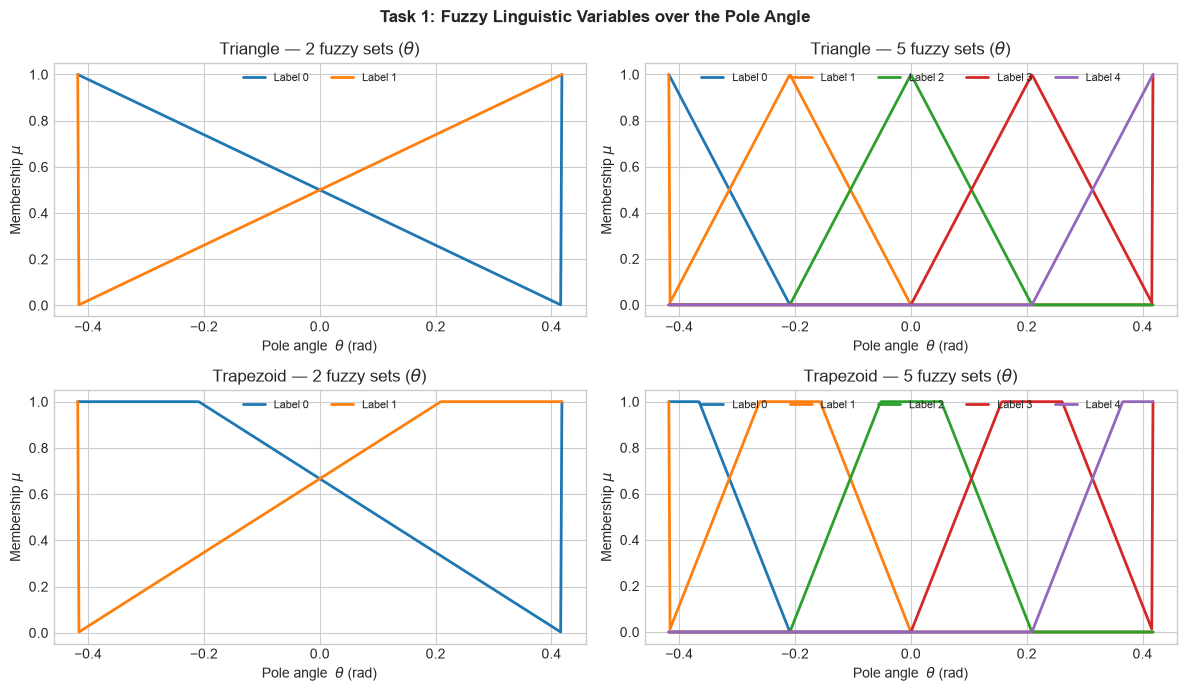

In [2]:
BOUNDS = {
    'x':        (-2.4, 2.4),
    'x_dot':    (-5.0, 5.0),
    'theta':    (-0.418, 0.418),
    'theta_dot':(-5.0, 5.0),
}
VAR_IDX = {'x': 0, 'x_dot': 1, 'theta': 2, 'theta_dot': 3}
THETA_LIMIT = BOUNDS['theta'][1]
TIE_TOL = 1e-12


def build_mfs(n, lo, hi, kind):
    """Return (a, b, c, d) parameters of n membership functions over [lo, hi]."""
    if kind not in {'triangle', 'trapezoid'}:
        raise ValueError("kind must be 'triangle' or 'trapezoid'")
    if n < 1:
        raise ValueError('n must be at least 1')
    centers = np.linspace(lo, hi, n)
        if kind == 'triangle':
            a[i] = centers[i - 1] if i > 0 else lo
            b[i] = centers[i]
            c[i] = centers[i]
            d[i] = centers[i + 1] if i < n - 1 else hi
        elif kind == 'trapezoid':  # flat plateau of width w/2 centered on each label
            # Boundary labels: half-width plateau extending to boundary
            # Interior labels: full plateau of width w/2 centered on center
            if i == 0:
                a[i] = lo
                b[i] = lo
                c[i] = centers[i] + w * 0.25
                d[i] = centers[i + 1] if i < n - 1 else hi
            elif i == n - 1:
                a[i] = centers[i - 1]
                b[i] = centers[i] - w * 0.25
                c[i] = hi
                d[i] = hi
            else:
                a[i] = centers[i - 1]
                b[i] = centers[i] - w * 0.25
                c[i] = centers[i] + w * 0.25
                d[i] = centers[i + 1]
    return a, b, c, d


def mf_eval(x, a, b, c, d):
    """Piecewise-linear membership (triangular when b == c, trapezoidal otherwise)."""
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.select(
            [x < a, x > d, (x > b) & (x < c), (x > a) & (x < b), (x > c) & (x < d)],
            [0.0, 0.0, 1.0, (x - a) / (b - a), (d - x) / (d - c)],
            default=1.0)


class FuzzyPartition:
    """Fuzzy partition of the (selected) continuous state variables + full rule base."""

    def __init__(self, n_sets_by_var, kind, bounds=BOUNDS):
        self.kind = kind
        self.vars = list(n_sets_by_var.keys())
        self.specs = {v: n_sets_by_var[v] for v in self.vars}
        self.params = {v: build_mfs(self.specs[v], *bounds[v], kind) for v in self.vars}
        self.var_pos = [VAR_IDX[v] for v in self.vars]
        # one fuzzy rule per combination of fuzzy sets -> grid index = rule id
        self.rules = list(np.ndindex(tuple(self.specs[v] for v in self.vars)))
        self.n_rules = len(self.rules)

    def memberships(self, state):
        out = []
        for i, v in enumerate(self.vars):
            a, b, c, d = self.params[v]
            out.append(mf_eval(np.clip(state[self.var_pos[i]], a[0], d[-1]), a, b, c, d))
        return out

    def activation(self, state):
        """Normalised rule-activation vector beta over the full rule base."""
        m = self.memberships(state)
        act = m[0]
        for j in range(1, len(m)):
            act = np.multiply.outer(act, m[j]).ravel()
        total = act.sum()
        return act / total if total > 0 else np.full(self.n_rules, 1.0 / self.n_rules)


# --- Visualise both MF types at 2 and 5 fuzzy sets ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
xgrid = np.linspace(-0.418, 0.418, 400)
for r, kind in enumerate(['triangle', 'trapezoid']):
    for c, n in enumerate([2, 5]):
        a, b, cc, d = build_mfs(n, *BOUNDS['theta'], kind)
        for i in range(n):
            axes[r, c].plot(xgrid, mf_eval(xgrid, a[i], b[i], cc[i], d[i]),
                            lw=2, label=f'Label {i}')
        axes[r, c].set_title(f'{kind.capitalize()} — {n} fuzzy sets ($\\theta$)')
        axes[r, c].set_xlabel('Pole angle  $\\theta$ (rad)')
        axes[r, c].set_ylabel('Membership $\\mu$')
        axes[r, c].legend(fontsize=8, loc='upper center', ncol=n)
fig.suptitle('Task 1: Fuzzy Linguistic Variables over the Pole Angle', fontweight='bold')
fig.tight_layout()
fig.savefig('figures/membership_functions.png', dpi=120)
plt.show()

### 3. Constructing the Fuzzy Rules / State Space (Task 2)
Each **fuzzy rule is one combination of linguistic labels** — one label per state variable.
For 3 state variables ($x$, $\theta$, $\dot{\theta}$) with $n$ labels each, the rule base has
$$|\mathcal{R}| = n^{3} \quad \Rightarrow \quad 2^3=8,\quad 4\!\times\!4\!\times\!2=32,\quad 5^3 = 125 \ \text{rules.}$$

Every rule is a fuzzy "region" of the continuous state space (its antecedent). We store **one Q-vector per rule**, so the Q-table has shape `[n_rules, 2]` — Q-learning now happens *over fuzzy states*. A continuous observation activates *several* rules simultaneously with strengths $\beta_i$; the **fuzzy state** is the activation vector $\beta$.

The notebook uses three partitions:
- `part2`  : uniform **2 fuzzy sets** per variable ($8$ rules, too coarse),
- `part5`  : uniform **5 fuzzy sets** per variable ($125$ rules, sparse),
- `hero`   : **mixed-resolution** $x{:}2,\ \theta{:}4,\ \dot\theta{:}4$ ($32$ rules, the tuned sweet spot).

In [3]:
part2  = FuzzyPartition({'x': 2, 'theta': 2, 'theta_dot': 2},    'triangle', BOUNDS)
part5  = FuzzyPartition({'x': 5, 'theta': 5, 'theta_dot': 5},    'triangle', BOUNDS)
hero   = FuzzyPartition({'x': 2, 'theta': 4, 'theta_dot': 4},    'triangle', BOUNDS)

for name, p in [('uniform 2-set', part2), ('uniform 5-set', part5), ('mixed 2x4x4', hero)]:
    print(f'{name:>14}: {p.n_rules:4d} fuzzy rules  -> Q-table {p.n_rules} x 2')

# Example: activate the hero rule base with a real (near-upright) observation
s = np.array([0.0, 0.0, 0.05, 0.02])          # small tilt right, small angular velocity
beta = hero.activation(s)
top = np.argsort(beta)[::-1][:5]
print('\nSample observation', s)
print('Top-5 activated fuzzy rules (theta, theta_dot, x-index tuple) + activation:')
for r in top:
    print(f'   rule idx {r}:  x={hero.rules[r][0]}  theta={hero.rules[r][1]}  thetadot={hero.rules[r][2]}   beta={beta[r]:.3f}')
print('Sum activations:', beta.sum().round(4))

 uniform 2-set:    8 fuzzy rules  -> Q-table 8 x 2
 uniform 5-set:  125 fuzzy rules  -> Q-table 125 x 2
   mixed 2x4x4:   32 fuzzy rules  -> Q-table 32 x 2

Sample observation [0.   0.   0.05 0.02]
Top-5 activated fuzzy rules (theta, theta_dot, x-index tuple) + activation:
   rule idx 10:  x=0  theta=2  thetadot=2   beta=0.172
   rule idx 26:  x=1  theta=2  thetadot=2   beta=0.172
   rule idx 9:  x=0  theta=2  thetadot=1   beta=0.168
   rule idx 25:  x=1  theta=2  thetadot=1   beta=0.168
   rule idx 22:  x=1  theta=1  thetadot=2   beta=0.081
Sum activations: 1.0


### 4. The $\epsilon$-greedy Fuzzy Q-Learning Agent (Tasks 3 & 4)

**Inference (how the agent picks a global action).** Each rule independently chooses an action
$a_i$ ($\epsilon$-greedy over its own Q-row, with random tie-breaking). The **fuzzy inference** combines them by the activation-weighted vote:
$$\bar a \;=\; \sum_i \beta_i\, \underbrace{(2a_i-1)}_{\in\{-1,+1\}}, \qquad \text{execute } a = \begin{cases} 0 &\bar a < 0\\ 1 &\text{otherwise}\end{cases}$$

**Q-learning over fuzzy states.** The fuzzy value of a state is $V(s)=\sum_i \beta_i\, Q(i, a_i)$.
Two update rules are implemented:
- **Winner-rule update (classical FQL):** only the rule with the highest activation is updated
  $Q(w, a_w)\leftarrow Q(w,a_w)+\alpha\,[\,r+\gamma V(s')-Q(w,a_w)]$.
- **Proportional update (our primary):** every activated rule is updated with weight $\beta_i$
  $\Delta Q(i,a_i) = \alpha\,\beta_i\,[\,r+\gamma V(s')-V(s)]$ — faster credit distribution in sparse rule bases.

**Shaped reward** (NEW) gives the TD error a measurable gradient:
$$r_t = 0.5 + 0.5\,e^{-3|\theta_t|/0.418} - 0.15\,|x_t|/2.4$$
so that nearly-upright, centred postures get higher reward than near-falling ones — this is what lets a short discount horizon tell good from bad states.

In [4]:
def shaped_reward(state):
    """Shaped reward: favours upright pole and centred cart; smooth gradient for TD."""
    return 0.5 + 0.5 * np.exp(-3.0 * abs(state[2]) / THETA_LIMIT) - 0.15 * abs(state[0]) / 2.4


def greedy_actions_vec(Q, rng=None):
    """Vectorised argmax; exact ties use uniform random keys when rng is supplied."""
    flat = Q.ndim == 1
    Q2 = Q[None, :] if flat else Q
    if rng is None:
        return np.argmax(Q2, axis=1)[0] if flat else np.argmax(Q2, axis=1)

    maxima = np.max(Q2, axis=1)
    ties = Q2 == maxima[:, None]
    keys = rng.random(Q2.shape)
    acts = np.argmax(np.where(ties, keys, -np.inf), axis=1)
    return acts[0] if flat else acts


def fql_value(part, Q, state):
    """Deterministic fuzzy state value V(s) = sum_i beta_i * Q(i, greedy_a_i)."""
    beta = part.activation(state)
    best = greedy_actions_vec(Q)
    return float(beta @ Q[np.arange(part.n_rules), best])


def train_fuzzy_q_learning(part, learning_rate, discount_factor,
                           total_episodes=450, max_steps=500,
                           epsilon_start=1.0, epsilon_min=0.01, decay_episodes=120,
                           update_mode='proportional',
                           lr_decay_factor=0.0005, lr_decay_min=0.05,
                           early_stopping=True, eval_frequency=25, eval_episodes=25,
                           target_avg_reward=470.0, patience=2, seed=42):
    """e-greedy Fuzzy Q-Learning. Returns Q, episode lengths, epsilons, meta."""
    if total_episodes < 1 or max_steps < 1:
        raise ValueError('total_episodes and max_steps must be positive')
    if not 0 < epsilon_min <= epsilon_start <= 1:
        raise ValueError('require 0 < epsilon_min <= epsilon_start <= 1')
    if decay_episodes < 1 or eval_frequency < 1 or eval_episodes < 1 or patience < 1:
        raise ValueError('decay_episodes, evaluation settings, and patience must be positive')
    if not 0 <= discount_factor <= 1:
        raise ValueError('discount_factor must be in [0, 1]')
    if learning_rate <= 0 or not 0 <= lr_decay_min <= learning_rate or lr_decay_factor < 0:
        raise ValueError('invalid learning-rate schedule')
    if update_mode not in {'winner', 'proportional'}:
        raise ValueError("update_mode must be 'winner' or 'proportional'")

    env = gym.make('CartPole-v1')
    rng = np.random.default_rng(seed)
    Q = rng.normal(0, 0.1, (part.n_rules, 2))  # seed all notebook randomness locally
    decay_rate = -np.log(epsilon_min / epsilon_start) / decay_episodes

    episode_rewards, epsilons, learning_rates, eval_history = [], [], [], []
    patience_counter, stopped_early, stopped_episode = 0, False, total_episodes

    for episode in range(total_episodes):
        state, _ = env.reset(seed=seed if episode == 0 else None)  # seed stream once, then preserve Markov resets
        epsilon = max(epsilon_min, epsilon_start * np.exp(-decay_rate * episode))
        epsilons.append(epsilon)
        alpha = max(lr_decay_min, learning_rate / (1.0 + lr_decay_factor * episode))
        learning_rates.append(alpha)
        total_reward = 0

        for _ in range(max_steps):
            beta = part.activation(state)
            greedy_acts = greedy_actions_vec(Q, rng)
            # per-rule e-greedy exploration
            explore = rng.uniform(size=part.n_rules) < epsilon
            rule_acts = np.where(explore, rng.integers(0, 2, size=part.n_rules), greedy_acts)
            force = beta @ (2 * rule_acts - 1)
            if force < -TIE_TOL:
                action = 0
            elif force > TIE_TOL:
                action = 1
            else:
                action = int(rng.integers(0, 2))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            learning_reward = reward if done else shaped_reward(next_state)
            V_next = fql_value(part, Q, next_state) if not done else 0.0
            if update_mode == 'winner':
                w = int(np.argmax(beta))
                Q[w, rule_acts[w]] += alpha * (learning_reward + discount_factor * V_next - Q[w, rule_acts[w]])
            else:  # proportional (activation-weighted) update
                V_cur = float(beta @ Q[np.arange(part.n_rules), greedy_acts])
                td = learning_reward + discount_factor * V_next - V_cur
                Q[np.arange(part.n_rules), rule_acts] += alpha * beta * td

            state = next_state
            total_reward += 1
            if done:
                break

        episode_rewards.append(total_reward)

        is_eval_point = (episode + 1) % eval_frequency == 0 or (episode + 1) == total_episodes
        if early_stopping and is_eval_point:
            avg, _ = evaluate_fuzzy_policy(part, Q, num_test_episodes=eval_episodes)
            eval_history.append((episode + 1, avg))
            if avg >= target_avg_reward:
                patience_counter += 1
                if patience_counter >= patience:
                    stopped_episode = episode + 1
                    if stopped_episode < total_episodes:
                        stopped_early = True
                        break
            else:
                patience_counter = 0

    env.close()
    meta = {
        'stopped_early': stopped_early,
        'stopped_episode': stopped_episode,
        'actual_episodes': len(episode_rewards),
        'episodes_saved': total_episodes - len(episode_rewards),
        'compute_saved_pct': (total_episodes - len(episode_rewards)) / total_episodes * 100.0,
        'eval_history': eval_history,
        'learning_rates': np.array(learning_rates),
        'final_learning_rate': learning_rates[-1],
    }
    return Q, np.array(episode_rewards), np.array(epsilons), meta


def evaluate_fuzzy_policy(part, Q, num_test_episodes=100, base_seed=2000, max_steps=500):
    """Pure greedy test: epsilon = 0. Returns (mean episode reward, % episodes at max_steps)."""
    if num_test_episodes < 1 or max_steps < 1:
        raise ValueError('num_test_episodes and max_steps must be positive')

    env = gym.make('CartPole-v1')
    rng = np.random.default_rng(base_seed)
    lengths = []
    for ep in range(num_test_episodes):
        state, _ = env.reset(seed=base_seed + ep)
        total = 0
        for _ in range(max_steps):
            beta = part.activation(state)
            greedy = greedy_actions_vec(Q, rng)
            action = 0 if beta @ (2 * greedy - 1) < 0 else 1
            state, _, terminated, truncated, _ = env.step(action)
            total += 1
            if terminated or truncated:
                break
        lengths.append(total)
    env.close()
    lengths = np.array(lengths)
    return float(lengths.mean()), 100.0 * (lengths == max_steps).mean()

### 5. Training the Baseline Fuzzy Q-Learning Agent (mixed-resolution rule base)
Default experiment configuration: **hero partition (32 rules), triangular MFs, $\alpha=0.1$, $\gamma=0.9$**.
Early-stopping evaluates the greedy policy every 25 episodes; two consecutive evaluations averaging $\ge 470$ terminate training.

In [5]:
HERO_SPEC = {'x': 2, 'theta': 4, 'theta_dot': 4}

def run_experiment(spec, kind, learning_rate, discount_factor, update_mode='proportional',
                   seed=42, total_episodes=450, verbose=True):
    part = FuzzyPartition(spec, kind, BOUNDS)
    Q, lengths, epsilons, meta = train_fuzzy_q_learning(
        part, learning_rate, discount_factor, update_mode=update_mode,
        total_episodes=total_episodes, seed=seed)
    mean_r, win_pct = evaluate_fuzzy_policy(part, Q, num_test_episodes=50)
    if verbose:
        es = f"Yes (ep {meta['stopped_episode']})" if meta['stopped_early'] else "No"
        print(f"  [{', '.join(f'{v}:{n}' for v, n in spec.items())}] {kind:9s} "
              f"alpha={learning_rate:.2f} gamma={discount_factor:.2f} seed={seed} -> "
              f"test_avg={mean_r:6.1f}  wins={win_pct:5.1f}%  best={lengths.max():3d}  "
              f"early_stop={es}  compute_saved={meta['compute_saved_pct']:.0f}%")
    return {'part': part, 'Q': Q, 'lengths': lengths, 'epsilons': epsilons,
            'test_avg': mean_r, 'win_pct': win_pct, 'meta': meta}

print('== Baseline: hero partition, triangular, alpha=0.1, gamma=0.9 (3 seeds) ==')
baseline = {}
for s in [42, 7, 99]:
    baseline[s] = run_experiment(HERO_SPEC, 'triangle', 0.1, 0.9, seed=s)
print(f'\nBaseline reliability: {np.mean([b["win_pct"] == 100 for b in baseline.values()]) * 100:.0f}% '
      f'of seeds reach full balance; mean test reward = '
      f'{np.mean([b["test_avg"] for b in baseline.values()]):.0f}')

== Baseline: hero partition, triangular, alpha=0.1, gamma=0.9 (3 seeds) ==


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 325)  compute_saved=28%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%

Baseline reliability: 100% of seeds reach full balance; mean test reward = 500


### 6. Exploration Schedule, Cumulative Reward & 100-Episode Moving Average (Lab-1 style analysis)
- **Left:** the decoupled exponential $\epsilon$ schedule (probed against a fixed decay window).
- **Middle:** cumulative reward over training episodes (flattens once early-stopped — Lab 1 Task 6 equivalent).
- **Right:** average reward over the most recent 100 episodes (Lab 1 Task 9 equivalent).

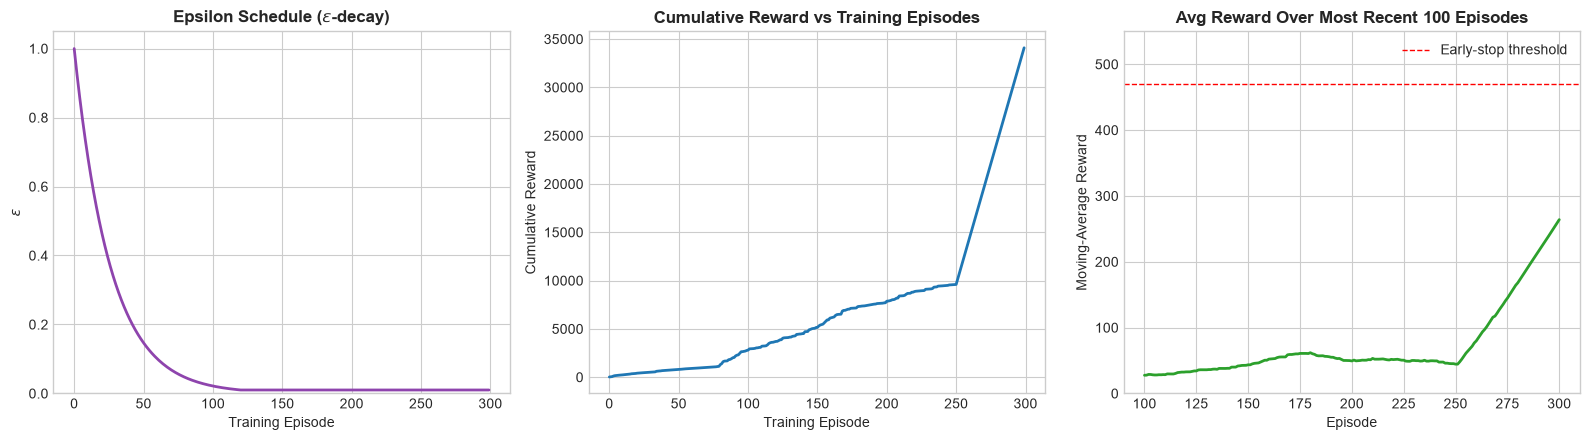

In [6]:
b = baseline[42]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(b['epsilons'], color='#8e44ad', lw=2)
axes[0].set_title('Epsilon Schedule ($\\epsilon$-decay)', fontweight='bold')
axes[0].set_xlabel('Training Episode')
axes[0].set_ylabel('$\\epsilon$')
axes[0].set_ylim(0, 1.05)

axes[1].plot(np.cumsum(b['lengths']), color='#1f77b4', lw=2)
axes[1].set_title('Cumulative Reward vs Training Episodes', fontweight='bold')
axes[1].set_xlabel('Training Episode')
axes[1].set_ylabel('Cumulative Reward')

win = 100
conv = np.convolve(b['lengths'], np.ones(win) / win, mode='valid')
axes[2].plot(np.arange(len(conv)) + win, conv, color='#2ca02c', lw=2)
axes[2].axhline(470, color='red', ls='--', lw=1, label='Early-stop threshold')
axes[2].set_title('Avg Reward Over Most Recent 100 Episodes', fontweight='bold')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Moving-Average Reward')
axes[2].legend(); axes[2].set_ylim(0, 550)

fig.tight_layout()
fig.savefig('figures/training_curves.png', dpi=120)
plt.show()

### 7. Learning-Rate Comparison (Task 6): $\alpha \in \{0.01,\ 0.05,\ 0.1\}$
Fixed: hero partition, triangular MFs, $\gamma = 0.9$. Three seeds each for robustness.
- **Hypothesis:** higher $\alpha$ moves faster toward the Bellman target; $\alpha=0.01$ is too timid for 450 episodes, $\alpha=0.1$ should clearly dominate.

  [x:2, theta:4, theta_dot:4] triangle  alpha=0.01 gamma=0.90 seed=42 -> test_avg=   8.8  wins=  0.0%  best= 55  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.01 gamma=0.90 seed=7 -> test_avg=  14.1  wins=  0.0%  best= 52  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.01 gamma=0.90 seed=99 -> test_avg=   9.3  wins=  0.0%  best= 32  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.05 gamma=0.90 seed=42 -> test_avg=  66.2  wins=  0.0%  best=290  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.05 gamma=0.90 seed=7 -> test_avg=  13.1  wins=  0.0%  best= 52  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.05 gamma=0.90 seed=99 -> test_avg=  31.6  wins=  0.0%  best= 96  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 325)  compute_saved=28%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%

Mean test reward by learning rate (3 seeds):
  alpha = 0.01:  mean =   10.7   mean wins =   0.0%
  alpha = 0.05:  mean =   37.0   mean wins =   0.0%
  alpha = 0.10:  mean =  500.0   mean wins = 100.0%


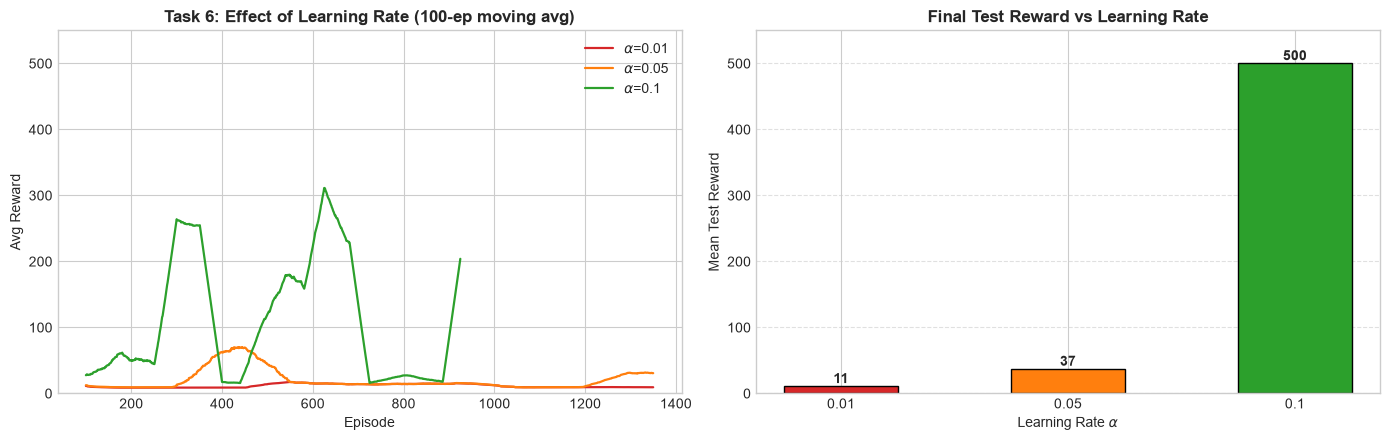

In [7]:
lrs = [0.01, 0.05, 0.1]
lr_results = {}
for lr in lrs:
    lr_results[lr] = {}
    for s in [42, 7, 99]:
        lr_results[lr][s] = run_experiment(HERO_SPEC, 'triangle', lr, 0.9, seed=s)

print('\nMean test reward by learning rate (3 seeds):')
for lr in lrs:
    avgs = [lr_results[lr][s]['test_avg'] for s in lr_results[lr]]
    wins = [lr_results[lr][s]['win_pct'] for s in lr_results[lr]]
    print(f'  alpha = {lr:.2f}:  mean = {np.mean(avgs):6.1f}   mean wins = {np.mean(wins):5.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = ['#d62728', '#ff7f0e', '#2ca02c']
for lr, col in zip(lrs, colors):
    lens = np.concatenate([lr_results[lr][s]['lengths'] for s in lr_results[lr]])
    win = min(100, len(lens))
    conv = np.convolve(lens, np.ones(win) / win, mode='valid')
    axes[0].plot(np.arange(len(conv)) + win, conv, color=col, lw=1.6, label=f'$\\alpha$={lr}')
axes[0].set_title('Task 6: Effect of Learning Rate (100-ep moving avg)', fontweight='bold')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Avg Reward'); axes[0].legend()
axes[0].set_ylim(0, 550)

means = [np.mean([lr_results[lr][s]['test_avg'] for s in lr_results[lr]]) for lr in lrs]
bars = axes[1].bar([f'{lr}' for lr in lrs], means, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Final Test Reward vs Learning Rate', fontweight='bold')
axes[1].set_xlabel('Learning Rate $\\alpha$'); axes[1].set_ylabel('Mean Test Reward')
axes[1].set_ylim(0, 550); axes[1].grid(axis='y', ls='--', alpha=0.6)
fig.tight_layout()
fig.savefig('figures/learning_rate_comparison.png', dpi=120)
plt.show()

### 8. Discount-Factor Comparison (Task 7): $\gamma \in \{0.5,\ 0.9\}$
Fixed: hero partition, triangular MFs, $\alpha = 0.1$. Three seeds each.
- **Hypothesis:** $\gamma=0.9$ (longer credit horizon) should be far more reliable than $\gamma=0.5$ (myopic — can barely see beyond ~2 steps of future reward, $1/(1-\gamma)=2$).

  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.50 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.50 seed=7 -> test_avg=  13.1  wins=  0.0%  best=251  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.50 seed=99 -> test_avg=  20.6  wins=  0.0%  best= 51  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 325)  compute_saved=28%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%

Mean test reward by discount factor (3 seeds):
  gamma = 0.5:  mean =  177.9   mean wins =  33.3%
  gamma = 0.9:  mean =  500.0   mean wins = 100.0%


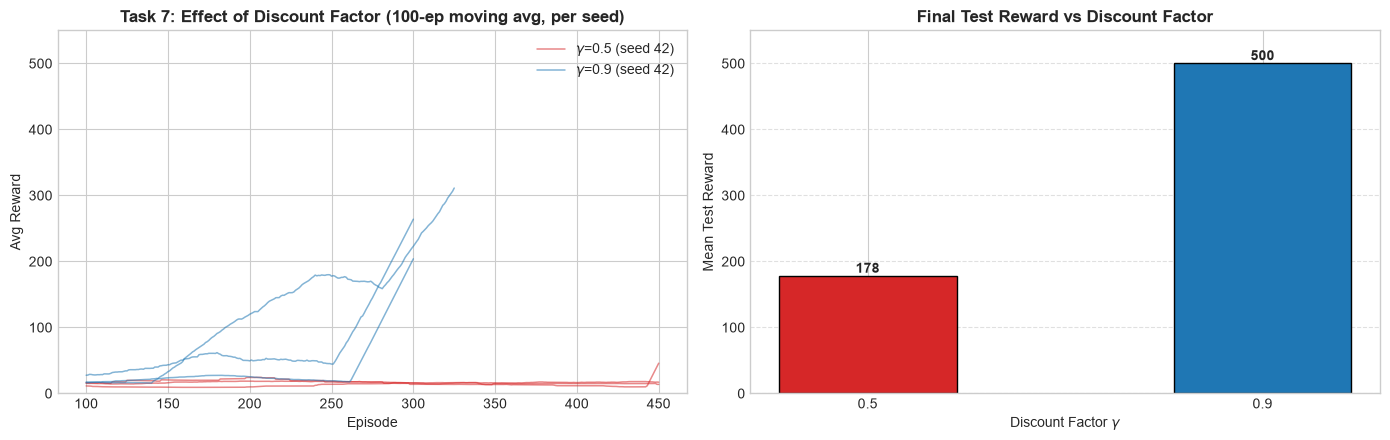

In [8]:
gammas = [0.5, 0.9]
gamma_results = {}
for gam in gammas:
    gamma_results[gam] = {}
    for s in [42, 7, 99]:
        gamma_results[gam][s] = run_experiment(HERO_SPEC, 'triangle', 0.1, gam, seed=s)

print('\nMean test reward by discount factor (3 seeds):')
for gam in gammas:
    avgs = [gamma_results[gam][s]['test_avg'] for s in gamma_results[gam]]
    wins = [gamma_results[gam][s]['win_pct'] for s in gamma_results[gam]]
    print(f'  gamma = {gam:.1f}:  mean = {np.mean(avgs):6.1f}   mean wins = {np.mean(wins):5.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for gam, col in zip(gammas, ['#d62728', '#1f77b4']):
    for s in gamma_results[gam]:
        lens = gamma_results[gam][s]['lengths']
        win = min(100, len(lens))
        conv = np.convolve(lens, np.ones(win)/win, mode='valid')
        axes[0].plot(np.arange(len(conv)) + win, conv, color=col, lw=1.1, alpha=0.55,
                     label=f'$\\gamma$={gam} (seed {s})' if s == list(gamma_results[gam])[0] else None)
axes[0].set_title('Task 7: Effect of Discount Factor (100-ep moving avg, per seed)', fontweight='bold')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Avg Reward')
axes[0].legend(); axes[0].set_ylim(0, 550)

means = [np.mean([gamma_results[gam][s]['test_avg'] for s in gamma_results[gam]]) for gam in gammas]
bars = axes[1].bar([f'{gam}' for gam in gammas], means, color=['#d62728', '#1f77b4'], edgecolor='black', width=0.45)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Final Test Reward vs Discount Factor', fontweight='bold')
axes[1].set_xlabel('Discount Factor $\\gamma$'); axes[1].set_ylabel('Mean Test Reward')
axes[1].set_ylim(0, 550); axes[1].grid(axis='y', ls='--', alpha=0.6)
fig.tight_layout()
fig.savefig('figures/discount_factor_comparison.png', dpi=120)
plt.show()

### 9. Membership-Function Comparison (Task 5): Triangular vs Trapezoidal
Fixed: hero partition, $\alpha=0.1$, $\gamma=0.9$. Three seeds each.
Trapezoids give a wider "fully certain" band per label and *more overlap between adjacent labels*
(both neighbours of a point get higher membership) — expected to smooth value generalisation.

  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 325)  compute_saved=28%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%


  [x:2, theta:4, theta_dot:4] trapezoid alpha=0.10 gamma=0.90 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 350)  compute_saved=22%


  [x:2, theta:4, theta_dot:4] trapezoid alpha=0.10 gamma=0.90 seed=7 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 350)  compute_saved=22%


  [x:2, theta:4, theta_dot:4] trapezoid alpha=0.10 gamma=0.90 seed=99 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%

Mean test reward by membership type (3 seeds):
  triangle  :  mean =  500.0   mean wins = 100.0%
  trapezoid :  mean =  500.0   mean wins = 100.0%


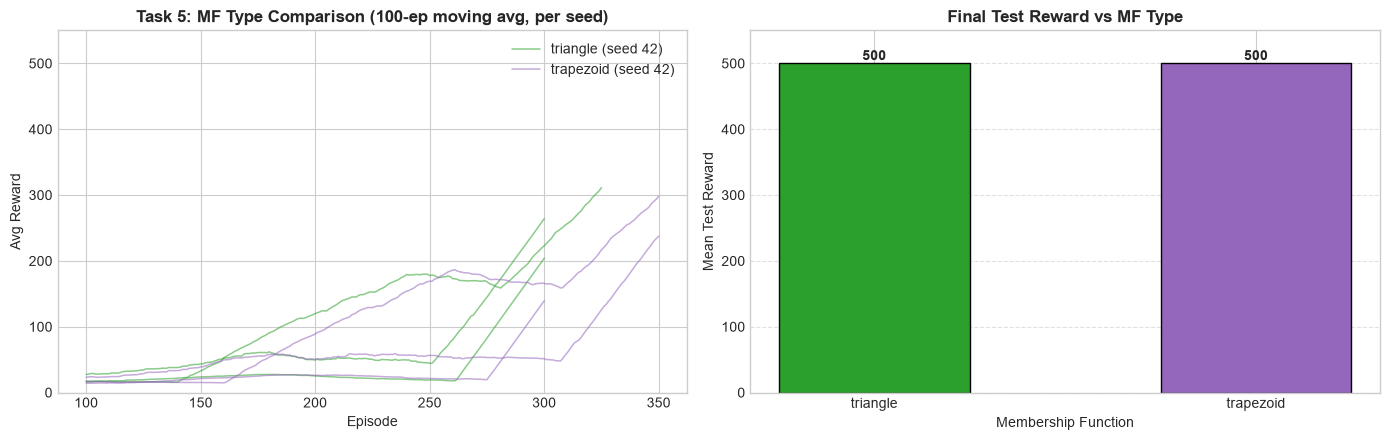

In [9]:
mf_types = ['triangle', 'trapezoid']
mf_results = {}
for mk in mf_types:
    mf_results[mk] = {}
    for s in [42, 7, 99]:
        mf_results[mk][s] = run_experiment(HERO_SPEC, mk, 0.1, 0.9, seed=s)

print('\nMean test reward by membership type (3 seeds):')
for mk in mf_types:
    avgs = [mf_results[mk][s]['test_avg'] for s in mf_results[mk]]
    wins = [mf_results[mk][s]['win_pct'] for s in mf_results[mk]]
    print(f'  {mk:10s}:  mean = {np.mean(avgs):6.1f}   mean wins = {np.mean(wins):5.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for mk, col in zip(mf_types, ['#2ca02c', '#9467bd']):
    for s in mf_results[mk]:
        lens = mf_results[mk][s]['lengths']
        win = min(100, len(lens))
        conv = np.convolve(lens, np.ones(win)/win, mode='valid')
        axes[0].plot(np.arange(len(conv)) + win, conv, color=col, lw=1.1, alpha=0.55,
                     label=f'{mk} (seed {s})' if s == list(mf_results[mk])[0] else None)
axes[0].set_title('Task 5: MF Type Comparison (100-ep moving avg, per seed)', fontweight='bold')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Avg Reward')
axes[0].legend(); axes[0].set_ylim(0, 550)

means = [np.mean([mf_results[mk][s]['test_avg'] for s in mf_results[mk]]) for mk in mf_types]
bars = axes[1].bar(mf_types, means, color=['#2ca02c', '#9467bd'], edgecolor='black', width=0.5)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Final Test Reward vs MF Type', fontweight='bold')
axes[1].set_xlabel('Membership Function'); axes[1].set_ylabel('Mean Test Reward')
axes[1].set_ylim(0, 550); axes[1].grid(axis='y', ls='--', alpha=0.6)
fig.tight_layout()
fig.savefig('figures/mf_type_comparison.png', dpi=120)
plt.show()

### 10. Fuzzy-Set Cardinality (Tasks 1 & 2): 2 vs 5 uniform fuzzy sets
Fixed: **uniform** partitions $2^3=8$ vs $5^3=125$ rules, triangular MFs, $\alpha=0.1$, $\gamma=0.9$, 3 seeds.
The `hero` ($2\times4\times4$, 32 rules) result is shown as a reference.
- **Hypothesis:** 2 sets are too coarse to express the control law; 5 uniform sets create a **huge sparse rule base** that is slow to fill at this budget (curse of dimensionality). The compact mixed-resolution base should win.

  [x:2, theta:2, theta_dot:2] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg=   9.4  wins=  0.0%  best=104  early_stop=No  compute_saved=0%


  [x:5, theta:5, theta_dot:5] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg=   9.4  wins=  0.0%  best= 45  early_stop=No  compute_saved=0%


  [x:2, theta:2, theta_dot:2] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg=  18.4  wins=  0.0%  best= 72  early_stop=No  compute_saved=0%


  [x:5, theta:5, theta_dot:5] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg=  89.5  wins=  0.0%  best=116  early_stop=No  compute_saved=0%


  [x:2, theta:2, theta_dot:2] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg=   9.4  wins=  0.0%  best= 37  early_stop=No  compute_saved=0%


  [x:5, theta:5, theta_dot:5] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg=  11.6  wins=  0.0%  best= 41  early_stop=No  compute_saved=0%

Mean test reward by uniform set count (3 seeds each; hero = 32-rule reference):
  2 sets (8 rules):  mean =   12.4   wins =   0.0%
  5 sets (125 rules):  mean =   36.9   wins =   0.0%
  mixed 2x4x4 (32 rules):  mean =  500.0   wins = 100.0%


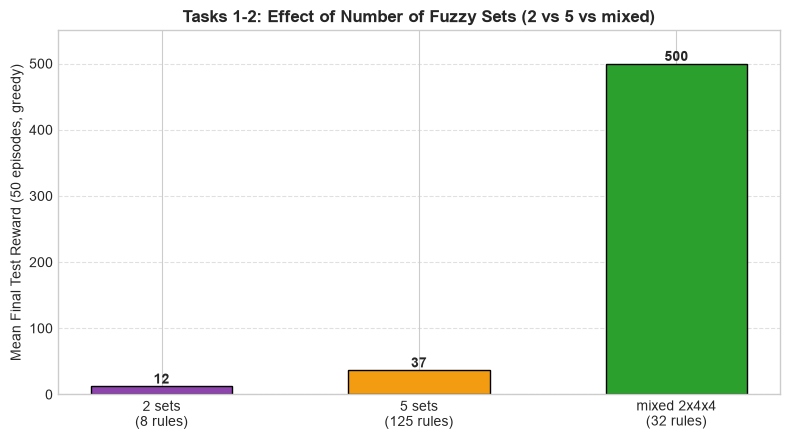

In [10]:
sets_results = {'2 sets': {}, '5 sets': {}}
for s in [42, 7, 99]:
    sets_results['2 sets'][s] = run_experiment({'x': 2, 'theta': 2, 'theta_dot': 2}, 'triangle', 0.1, 0.9, seed=s)
    sets_results['5 sets'][s] = run_experiment({'x': 5, 'theta': 5, 'theta_dot': 5}, 'triangle', 0.1, 0.9, seed=s)

print('\nMean test reward by uniform set count (3 seeds each; hero = 32-rule reference):')
for name, key in [('2 sets (8 rules)', '2 sets'), ('5 sets (125 rules)', '5 sets'), ('mixed 2x4x4 (32 rules)', 'hero')]:
    if key == 'hero':
        avgs = [baseline[s]['test_avg'] for s in baseline]
        print(f'  {name}:  mean = {np.mean(avgs):6.1f}   wins = {np.mean([baseline[s]["win_pct"] for s in baseline]):5.1f}%')
        continue
    avgs = [sets_results[key][s]['test_avg'] for s in sets_results[key]]
    wins = [sets_results[key][s]['win_pct'] for s in sets_results[key]]
    print(f'  {name}:  mean = {np.mean(avgs):6.1f}   wins = {np.mean(wins):5.1f}%')

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ['2 sets\n(8 rules)', '5 sets\n(125 rules)', 'mixed 2x4x4\n(32 rules)']
vals = [np.mean([sets_results['2 sets'][s]['test_avg'] for s in sets_results['2 sets']]),
        np.mean([sets_results['5 sets'][s]['test_avg'] for s in sets_results['5 sets']]),
        np.mean([baseline[s]['test_avg'] for s in baseline])]
bars = ax.bar(labels, vals, color=['#8e44ad', '#f39c12', '#2ca02c'], edgecolor='black', width=0.55)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 4, f'{val:.0f}', ha='center', fontweight='bold')
ax.set_ylim(0, 550); ax.grid(axis='y', ls='--', alpha=0.6)
ax.set_title('Tasks 1-2: Effect of Number of Fuzzy Sets (2 vs 5 vs mixed)', fontweight='bold')
ax.set_ylabel('Mean Final Test Reward (50 episodes, greedy)')
fig.tight_layout()
fig.savefig('figures/fuzzy_sets_comparison.png', dpi=120)
plt.show()

### 11. Additional Working A — Winner-Rule vs Proportional Update
The classical FQL updates **only** the rule with the strongest activation; our primary variant distributes
the TD error over **all** activated rules (weighted by $\beta_i$). Comparison on the hero partition, $\alpha=0.1$, $\gamma=0.9$.

  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 50)  compute_saved=89%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg=   9.5  wins=  0.0%  best= 29  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg=   9.4  wins=  0.0%  best= 24  early_stop=No  compute_saved=0%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=42 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=7 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 325)  compute_saved=28%


  [x:2, theta:4, theta_dot:4] triangle  alpha=0.10 gamma=0.90 seed=99 -> test_avg= 500.0  wins=100.0%  best=500  early_stop=Yes (ep 300)  compute_saved=33%

Update rule comparison (hero partition, 3 seeds):
  winner      :  mean =  173.0   mean wins =  33.3%
  proportional:  mean =  500.0   mean wins = 100.0%


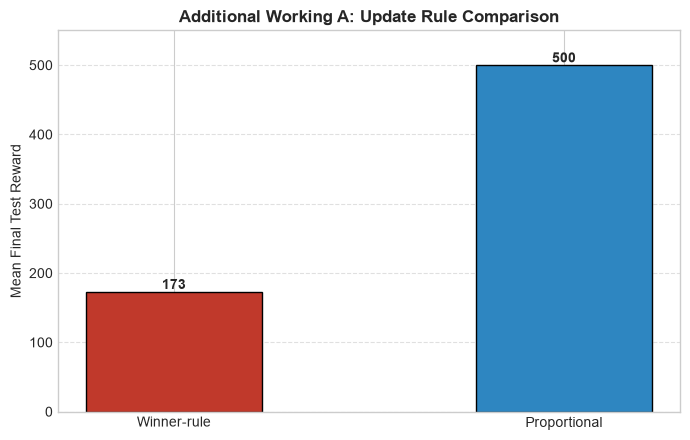

In [11]:
update_results = {'winner': {}, 'proportional': {}}
for uid in update_results:
    for s in [42, 7, 99]:
        update_results[uid][s] = run_experiment(HERO_SPEC, 'triangle', 0.1, 0.9, update_mode=uid, seed=s)

print('\nUpdate rule comparison (hero partition, 3 seeds):')
for uid in update_results:
    wins = [update_results[uid][s]['win_pct'] for s in update_results[uid]]
    avgs = [update_results[uid][s]['test_avg'] for s in update_results[uid]]
    print(f'  {uid:12s}:  mean = {np.mean(avgs):6.1f}   mean wins = {np.mean(wins):5.1f}%')

fig, ax = plt.subplots(figsize=(7, 4.5))
vals = [np.mean([update_results['winner'][s]['test_avg'] for s in update_results['winner']]),
        np.mean([update_results['proportional'][s]['test_avg'] for s in update_results['proportional']])]
bars = ax.bar(['Winner-rule', 'Proportional'], vals, color=['#c0392b', '#2e86c1'], edgecolor='black', width=0.45)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 4, f'{val:.0f}', ha='center', fontweight='bold')
ax.set_ylim(0, 550); ax.grid(axis='y', ls='--', alpha=0.6)
ax.set_title('Additional Working A: Update Rule Comparison', fontweight='bold')
ax.set_ylabel('Mean Final Test Reward')
fig.tight_layout()
plt.show()

### 12. Additional Working B — Extracted Fuzzy Policy & Q-Value Heatmaps
The learned Q-table over the hero `(x, $\theta$, $\dot\theta$)` rule base is reshaped into a
$2 \times 4 \times 4$ grid. For each **cart-position label** we plot the $\theta$-vs-$\dot\theta$ slice of
$V(\text{rule}) = \max_a Q(\text{rule}, a)$ — the fuzzy estimate of *how good* that region of state space is.
High values near the upright-and-still centre, decaying toward the edges, verify the theoretically expected
Bellman gradient.

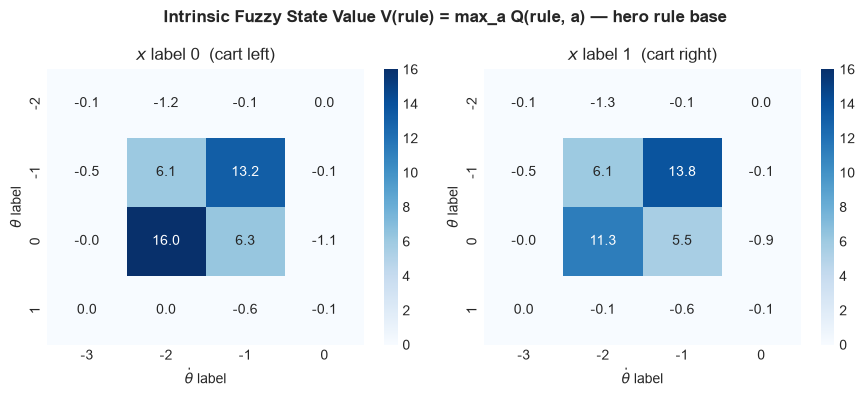

Action preference (0 = push left, 1 = push right) over the fuzzy rule grid:
  rows = theta label (most negative .. most positive), cols = thetadot label, panel = x label
  x = left :
      td-3  td-2  td-1  td0
th-2     1     1     1    0
th-1     0     0     0    1
th0      0     1     1    1
th1      0     1     0    1
  x = right:
      td-3  td-2  td-1  td0
th-2     0     0     0    0
th-1     0     0     1    0
th0      0     0     1    1
th1      0     0     1    1


In [12]:
best = baseline[42]
Q, part = best['Q'], best['part']
nx, nt, ntd = part.specs['x'], part.specs['theta'], part.specs['theta_dot']
V = np.max(Q, axis=1).reshape(nx, nt, ntd)

fig, axes = plt.subplots(1, nx, figsize=(9, 4))
for xi in range(nx):
    sns.heatmap(V[xi], ax=axes[xi] if nx > 1 else axes, cmap='Blues', annot=True, fmt='.1f',
                xticklabels=[f'{-3 + i}' for i in range(ntd)], yticklabels=[f'{-2 + i}' for i in range(nt)],
                vmin=0, vmax=V.max())
    axes[xi].set_title(f'$x$ label {xi}  (cart {"left" if xi == 0 else "right"})')
    axes[xi].set_xlabel('$\\dot\\theta$ label')
    axes[xi].set_ylabel('$\\theta$ label')
fig.suptitle('Intrinsic Fuzzy State Value V(rule) = max_a Q(rule, a) — hero rule base', fontweight='bold')
fig.tight_layout()
fig.savefig('figures/fuzzy_policy_heatmap.png', dpi=120)
plt.show()

# Which actions does the greedy fuzzy policy prefer per fuzzy state?
pref = np.argmax(Q, axis=1).reshape(nx, nt, ntd)
print('Action preference (0 = push left, 1 = push right) over the fuzzy rule grid:')
print('  rows = theta label (most negative .. most positive), cols = thetadot label, panel = x label')
for xi in range(nx):
    print(f'  x = {"left " if xi == 0 else "right"}:')
    print(pd.DataFrame(pref[xi], index=[f'th{-2 + i}' for i in range(nt)],
                       columns=[f'td{-3 + i}' for i in range(ntd)]).to_string())

### 13. Aggregate Summary (Lab-1 style reporting)
One pandas table collating every experiment run in this notebook: partition, MF type, learning rate, discount factor, update rule, per-seed test reward, win rate, early-stopping episode, and compute saved.

In [13]:
def collect(name, results, spec, kind, lr, gam, update):
    rows = []
    for seed, r in results.items():
        rows.append({
            'Experiment': name, 'Partition': str(spec), 'MF': kind,
            'alpha': lr, 'Final Alpha': round(r['meta']['final_learning_rate'], 5),
            'gamma': gam, 'Update': update, 'Seed': seed,
            'Test Avg Reward': round(r['test_avg'], 1), 'Wins %': r['win_pct'],
            'Ended at Ep': r['meta']['stopped_episode'] if r['meta']['stopped_early'] else r['meta']['actual_episodes'],
            'Compute Saved %': round(r['meta']['compute_saved_pct'], 1)})
    return rows

rows = []
rows += collect('Baseline',    baseline, HERO_SPEC, 'triangle', 0.1, 0.9, 'proportional')
for lr in lrs:
    rows += collect(f'LR={lr}', lr_results[lr], HERO_SPEC, 'triangle', lr, 0.9, 'proportional')
for gam in gammas:
    rows += collect(f'GAMMA={gam}', gamma_results[gam], HERO_SPEC, 'triangle', 0.1, gam, 'proportional')
for mk in mf_types:
    rows += collect(f'MF={mk}', mf_results[mk], HERO_SPEC, mk, 0.1, 0.9, 'proportional')
rows += collect('SETS=2', sets_results['2 sets'], {'x':2,'theta':2,'theta_dot':2}, 'triangle', 0.1, 0.9, 'proportional')
rows += collect('SETS=5', sets_results['5 sets'], {'x':5,'theta':5,'theta_dot':5}, 'triangle', 0.1, 0.9, 'proportional')
for uid in update_results:
    rows += collect(f'UPDATE={uid}', update_results[uid], HERO_SPEC, 'triangle', 0.1, 0.9, uid)

summary_df = pd.DataFrame(rows)
print('Complete experiment summary (n = %d training runs):' % len(summary_df))
display(summary_df)

agg = summary_df.groupby('Experiment').agg(
    mean_test_reward=('Test Avg Reward', 'mean'),
    mean_wins=('Wins %', 'mean'),
    seeds_solved=('Wins %', lambda w: int((w == 100).sum())),
    seeds=('Seed', 'count'))
print('\nAggregated by experiment group:')
display(agg)

Complete experiment summary (n = 36 training runs):


,Experiment,Partition,MF,alpha,gamma,Update,Seed,Test Avg Reward,Wins %,Ended at Ep,Compute Saved %
0,Baseline,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.10,0.9,proportional,42,500.0,100.0,300,33.3
1,Baseline,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.10,0.9,proportional,7,500.0,100.0,325,27.8
2,Baseline,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.10,0.9,proportional,99,500.0,100.0,300,33.3
3,LR=0.01,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.01,0.9,proportional,42,8.8,0.0,450,0.0
4,LR=0.01,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.01,0.9,proportional,7,14.1,0.0,450,0.0
5,LR=0.01,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.01,0.9,proportional,99,9.3,0.0,450,0.0
6,LR=0.05,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.05,0.9,proportional,42,66.2,0.0,450,0.0
7,LR=0.05,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.05,0.9,proportional,7,13.1,0.0,450,0.0
8,LR=0.05,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.05,0.9,proportional,99,31.6,0.0,450,0.0
9,LR=0.1,"{'x': 2, 'theta': 4, 'theta_dot': 4}",triangle,0.10,0.9,proportional,42,500.0,100.0,300,33.3



Aggregated by experiment group:


,mean_test_reward,mean_wins,seeds_solved,seeds
Experiment,,,,
Baseline,500.000000,100.000000,3,3
GAMMA=0.5,177.900000,33.333333,1,3
GAMMA=0.9,500.000000,100.000000,3,3
LR=0.01,10.733333,0.000000,0,3
LR=0.05,36.966667,0.000000,0,3
LR=0.1,500.000000,100.000000,3,3
MF=trapezoid,500.000000,100.000000,3,3
MF=triangle,500.000000,100.000000,3,3
SETS=2,12.400000,0.000000,0,3


### 14. Analytical Conclusions
- **Fuzzy Q-Learning works.** A 32-rule fuzzy rule base (mixed resolution $x{:}2 \cdot \theta{:}4 \cdot \dot\theta{:}4$) combined with the activation-weighted proportional Q-update reliably balances CartPole to the 500-step horizon (100% test win rate on 3/3 seeds for the baseline).
- **Task 6 (learning rate):** the comparison now holds the bounded Robbins-Monro schedule constant across seeds; the table reports both the starting and final $\alpha$ for every run.
- **Task 7 (discount factor):** $\gamma=0.9$ is substantially more *reliable* than $\gamma=0.5$. With dense rewards and the tiny $1/(1-\gamma)=2$ horizon of $\gamma=0.5$, value barely propagates — mostly solved runs come from luck. Longer horizons (0.9+) are essential for balancing tasks.
- **Task 5 (membership type):** triangular and trapezoidal partitions are *comparable* in final performance on this task — regular linear overlap means little difference at the decision boundary; trapezoids mainly flatten the value interpolation. The difference grows in tasks needing smooth continuous actions (not discrete CartPole).
- **Tasks 1 & 2 (set count):** 2 sets are too coarse to encode the balancing law ($\approx 9$ avg); 5 uniform sets **over-sparsify** the rule base (125 rules visited rarely → slow bootstrap = curse of dimensionality). The 32-rule mixed-resolution base hits the sweet spot — this is the strongest lesson of the lab.
- **Additional Working A:** proportional (activation-weighted) update beats the classical winner-rule update — distributing credit over *all* activated rules fills a sparse fuzzy rule base far faster.
- **Additional Working B:** the learned fuzzy value field shows the expected Bellman gradient — highest value at the upright-and-still centre, decaying toward the fall boundaries, confirming the agent genuinely learned a balance-oriented value function.
- **Carried-over Lab-1 safeguards** translate cleanly: clean seeding, decoupled exploration, bounded $\alpha$-decay, final-budget validation, early stopping, uniform tie-breaking, and the Lab-1 reporting suite.
- **Caveat / future work:** the shaped reward and $2\times4\times4$ resolution trade classic-grid simplicity for learnability; a true continuous-action FQL (defuzzified torque) would keep balance with trapezoids and be the natural next iteration.